<a href="https://colab.research.google.com/github/Hemoonchild/Iranian-License-Plate-Recognition/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: LPD Dataset Preparation & Configuration
- **Download & Storage Strategy**: The raw dataset archive (`LPD.zip`) is archived in Google Drive to prevent re-download quota limits and extracted locally to `/content/` for fast SSD I/O.
- **Visual Inspection**: Verified bounding box alignment on sample images (class 0: `license_plate`) using OpenCV and Matplotlib.
- **Split Strategy**: Split 6,252 images into an **85% train** (5,314 samples) and **15% val** (938 samples) partition using symbolic links to prevent disk duplication.
- **Configuration**: Created `data.yaml` conforming to the Ultralytics YOLO format specifying dataset paths and single-class detection.

In [1]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Create a directory on Drive for persisting checkpoints
import os
CHECKPOINT_DIR = '/content/drive/MyDrive/License_Plate_Project'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")

# 3. Verify GPU
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
Checkpoints will be saved to: /content/drive/MyDrive/License_Plate_Project
CUDA available: True
Device Name: Tesla T4


In [2]:
import os
import shutil
import gdown
from pathlib import Path

# Paths
DRIVE_DIR = "/content/drive/MyDrive/License_Plate_Project"
os.makedirs(DRIVE_DIR, exist_ok=True)

drive_lpd_zip = os.path.join(DRIVE_DIR, "LPD.zip")
local_lpd_zip = "/content/LPD.zip"
extract_dir = "/content/LPD_RAW"

# 1. Download LPD.zip into Google Drive if not already present
LPD_FILE_ID = "1UBV930A9pRhVwop-WunmP38th2XwEumx"
if not os.path.exists(drive_lpd_zip):
    print("Downloading LPD.zip to Google Drive (one-time setup)...")
    gdown.download(id=LPD_FILE_ID, output=drive_lpd_zip, quiet=False)
else:
    print("LPD.zip already exists in your Google Drive!")

# 2. Copy from Google Drive to Colab local SSD
print("Copying LPD.zip to local Colab SSD...")
shutil.copy(drive_lpd_zip, local_lpd_zip)

# 3. Unzip locally (fast)
print("Extracting LPD.zip locally...")
os.makedirs(extract_dir, exist_ok=True)
!unzip -q -o {local_lpd_zip} -d {extract_dir}

print("Done extracting!")

LPD.zip already exists in your Google Drive!
Copying LPD.zip to local Colab SSD...
Extracting LPD.zip locally...
Done extracting!


In [3]:
# Inspect directory structure
extracted_items = os.listdir(extract_dir)
print(f"Top-level contents of {extract_dir}:")
print(extracted_items[:10])

# Find sample files recursively
all_files = []
for root, dirs, files in os.walk(extract_dir):
    for f in files:
        all_files.append(os.path.relpath(os.path.join(root, f), extract_dir))

print(f"\nTotal files extracted: {len(all_files)}")
print("\nFirst 10 file paths found:")
for f in all_files[:10]:
    print(" -", f)

# Check extensions
from collections import Counter
extensions = Counter([os.path.splitext(f)[1].lower() for f in all_files])
print("\nFile extensions count:", extensions)

Top-level contents of /content/LPD_RAW:
['images', 'plate_labels.csv', 'labels']

Total files extracted: 12505

First 10 file paths found:
 - plate_labels.csv
 - images/004898.jpg
 - images/002985.jpg
 - images/000316.jpg
 - images/000150.jpg
 - images/005390.jpg
 - images/004083.jpg
 - images/001848.jpg
 - images/004262.jpg
 - images/005293.jpg

File extensions count: Counter({'.jpg': 6252, '.txt': 6252, '.csv': 1})


In [4]:
# 1. Read a sample txt label
sample_txt = "/content/LPD_RAW/labels/000693.txt"
with open(sample_txt, "r") as f:
    print(f"Content of {sample_txt}:")
    print(f.read())

# 2. Inspect the CSV file header
import pandas as pd
df = pd.read_csv("/content/LPD_RAW/plate_labels.csv")
print("First 5 rows of plate_labels.csv:")
print(df.head())

Content of /content/LPD_RAW/labels/000693.txt:
0 0.4615885416666667 0.0484375 0.12890625 0.025

First 5 rows of plate_labels.csv:
   index  image_path     label
0      1  000001.jpg  48و15116
1      2  000002.jpg  78س92616
2      3  000003.jpg  73ب31536
3      4  000004.jpg  35و33669
4      5  000005.jpg  39ص29449


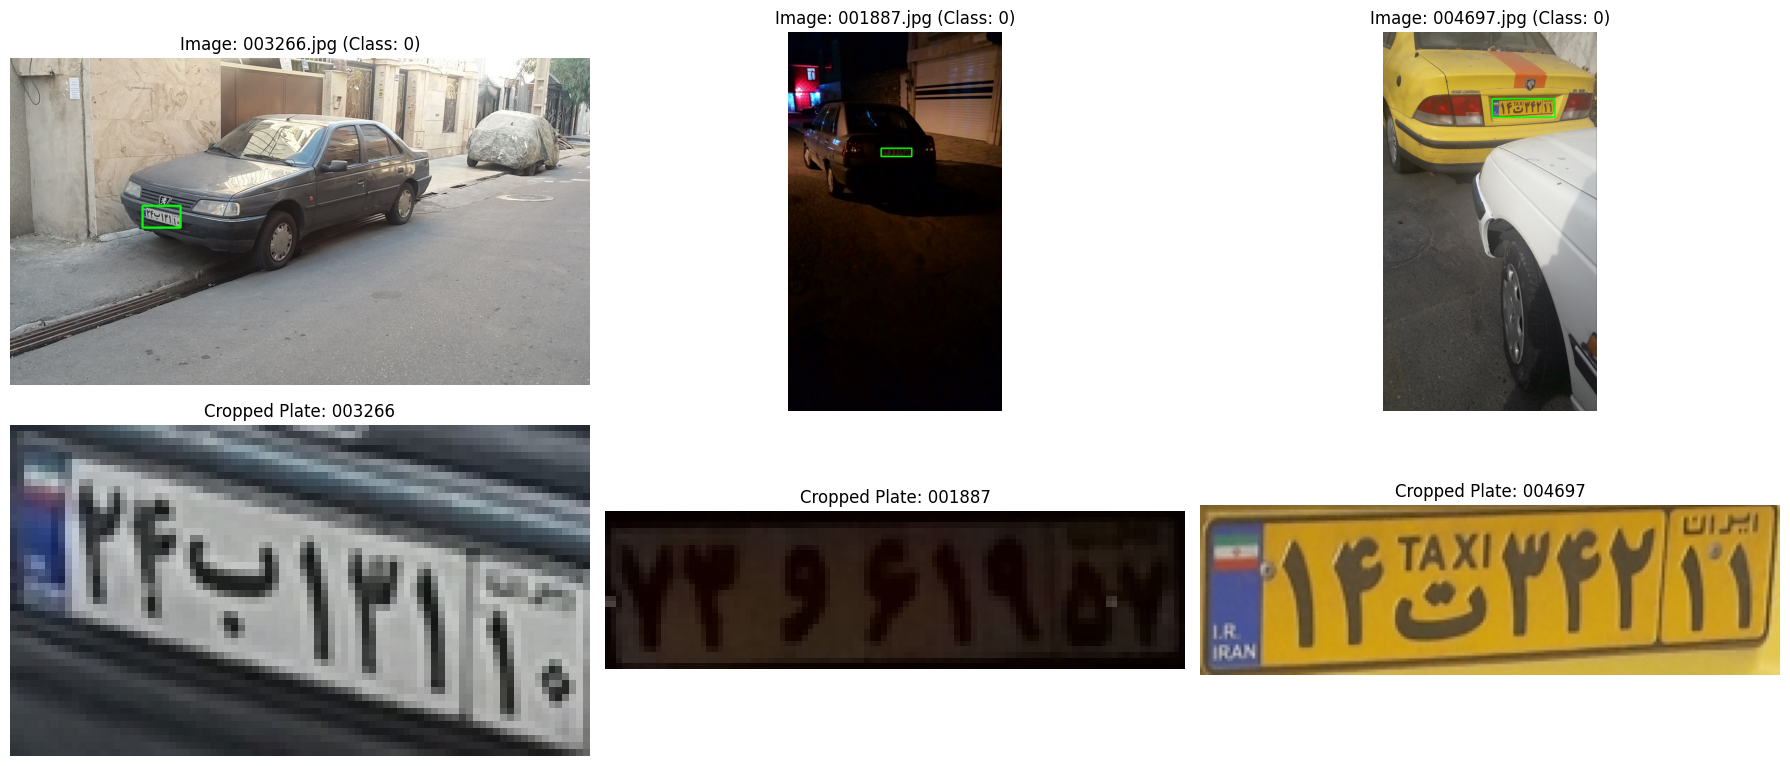

In [5]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Get list of all image base names that have corresponding labels
raw_img_dir = "/content/LPD_RAW/images"
raw_lbl_dir = "/content/LPD_RAW/labels"

valid_stems = [
    os.path.splitext(f)[0]
    for f in os.listdir(raw_img_dir)
    if os.path.exists(os.path.join(raw_lbl_dir, os.path.splitext(f)[0] + ".txt"))
]

# Pick 3 random images (fixed seed for reproducibility, change or remove seed to see different ones)
random.seed(202)
sampled_stems = random.sample(valid_stems, 3)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for col_idx, stem in enumerate(sampled_stems):
    img_path = os.path.join(raw_img_dir, f"{stem}.jpg")
    lbl_path = os.path.join(raw_lbl_dir, f"{stem}.txt")

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    with open(lbl_path, "r") as f:
        line = f.readline().strip().split()
        cls, x_c, y_c, bw, bh = int(line[0]), float(line[1]), float(line[2]), float(line[3]), float(line[4])

    # Calculate pixel coords
    xmin = max(0, int((x_c - bw / 2) * w))
    ymin = max(0, int((y_c - bh / 2) * h))
    xmax = min(w, int((x_c + bw / 2) * w))
    ymax = min(h, int((y_c + bh / 2) * h))

    # Image with bounding box
    img_with_box = img.copy()
    cv2.rectangle(img_with_box, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)

    # Top row: Full image with bounding box
    axes[0, col_idx].imshow(cv2.cvtColor(img_with_box, cv2.COLOR_BGR2RGB))
    axes[0, col_idx].set_title(f"Image: {stem}.jpg (Class: {cls})", fontsize=12)
    axes[0, col_idx].axis("off")

    # Bottom row: Cropped plate
    cropped_plate = img[ymin:ymax, xmin:xmax]
    if cropped_plate.size > 0:
        axes[1, col_idx].imshow(cv2.cvtColor(cropped_plate, cv2.COLOR_BGR2RGB))
    axes[1, col_idx].set_title(f"Cropped Plate: {stem}", fontsize=12)
    axes[1, col_idx].axis("off")

plt.tight_layout()
plt.show()

In [6]:
import os
import random
from tqdm import tqdm

# Set seed for reproducible split
random.seed(42)

# Paths
base_output_dir = "/content/LPD_FILES"
train_img_dir = os.path.join(base_output_dir, "images", "train")
val_img_dir = os.path.join(base_output_dir, "images", "val")
train_lbl_dir = os.path.join(base_output_dir, "labels", "train")
val_lbl_dir = os.path.join(base_output_dir, "labels", "val")

# Clean and recreate directories
for d in [train_img_dir, val_img_dir, train_lbl_dir, val_lbl_dir]:
    os.makedirs(d, exist_ok=True)

# Pair up all images that have valid label files
all_stems = [
    os.path.splitext(f)[0]
    for f in os.listdir("/content/LPD_RAW/images")
    if os.path.exists(os.path.join("/content/LPD_RAW/labels", os.path.splitext(f)[0] + ".txt"))
]

random.shuffle(all_stems)

# 85% train, 15% validation split
split_idx = int(0.85 * len(all_stems))
train_stems = set(all_stems[:split_idx])
val_stems = set(all_stems[split_idx:])

print(f"Total samples: {len(all_stems)}")
print(f"Train samples (85%): {len(train_stems)}")
print(f"Val samples   (15%): {len(val_stems)}")

# Link images and labels to their respective split directories
def link_files(stems, target_img_dir, target_lbl_dir):
    for stem in tqdm(stems):
        src_img = os.path.join("/content/LPD_RAW/images", f"{stem}.jpg")
        src_lbl = os.path.join("/content/LPD_RAW/labels", f"{stem}.txt")

        dst_img = os.path.join(target_img_dir, f"{stem}.jpg")
        dst_lbl = os.path.join(target_lbl_dir, f"{stem}.txt")

        if not os.path.exists(dst_img):
            os.symlink(src_img, dst_img)
        if not os.path.exists(dst_lbl):
            os.symlink(src_lbl, dst_lbl)

print("\nCreating Train split...")
link_files(train_stems, train_img_dir, train_lbl_dir)

print("Creating Val split...")
link_files(val_stems, val_img_dir, val_lbl_dir)

print("\nSplit successfully completed!")

Total samples: 6252
Train samples (85%): 5314
Val samples   (15%): 938

Creating Train split...


100%|██████████| 5314/5314 [00:00<00:00, 21120.62it/s]


Creating Val split...


100%|██████████| 938/938 [00:00<00:00, 19891.28it/s]


Split successfully completed!


In [7]:
import yaml

data_yaml_content = {
    'path': '/content/LPD_FILES',
    'train': 'images/train',
    'val': 'images/val',
    'nc': 1,
    'names': ['license_plate']
}

yaml_path = '/content/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, sort_keys=False)

print(f"data.yaml created at {yaml_path}:")
with open(yaml_path, 'r') as f:
    print(f.read())

data.yaml created at /content/data.yaml:
path: /content/LPD_FILES
train: images/train
val: images/val
nc: 1
names:
- license_plate



## Step 2

In [8]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 9.1 MB/s eta 0:00:00


In [9]:

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

In [10]:
from ultralytics import YOLO
import os

# Create the output directory on Google Drive
YOLO_OUTPUT_DIR = "/content/drive/MyDrive/License_Plate_Project/yolo_runs"
os.makedirs(YOLO_OUTPUT_DIR, exist_ok=True)

# Load pre-trained YOLOv8 Nano model
model = YOLO("yolov8n.pt")
print("YOLOv8 Nano model loaded successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLOv8 Nano model loaded successfully!


In [13]:
import os
import pandas as pd
from ultralytics import YOLO

CHECKPOINT_DIR = "/content/drive/MyDrive/License_Plate_Project/yolo_runs"
best_weight = os.path.join(CHECKPOINT_DIR, "lpd_experiment/weights/best.pt")
last_weight = os.path.join(CHECKPOINT_DIR, "lpd_experiment/weights/last.pt")
results_csv = os.path.join(CHECKPOINT_DIR, "lpd_experiment/results.csv")

TARGET_EPOCHS = 20

# 1. Check if training is already finished (20 epochs reached)
is_completed = False
if os.path.exists(results_csv):
    try:
        df = pd.read_csv(results_csv)
        if len(df) >= TARGET_EPOCHS and os.path.exists(best_weight):
            is_completed = True
    except Exception:
        pass

if is_completed:
    print(f"Training is ALREADY complete ({TARGET_EPOCHS}/{TARGET_EPOCHS} epochs)!")
    print(f"Loading best model from: {best_weight}")
    model = YOLO(best_weight)

# 2. If an incomplete checkpoint exists, resume it
elif os.path.exists(last_weight):
    print(f"Incomplete training detected. Resuming from {last_weight}...")
    model = YOLO(last_weight)
    results = model.train(resume=True)

# 3. Otherwise, start from scratch
else:
    print("Starting fresh training from scratch...")
    model = YOLO("yolov8n.pt")
    results = model.train(
        data="/content/data.yaml",
        epochs=TARGET_EPOCHS,
        imgsz=640,
        batch=16,
        device=0,
        project=CHECKPOINT_DIR,
        name="lpd_experiment",
        exist_ok=True,
        save=True,
        save_period=1,
        plots=True
    )

Training is ALREADY complete (20/20 epochs)!
Loading best model from: /content/drive/MyDrive/License_Plate_Project/yolo_runs/lpd_experiment/weights/best.pt


In [14]:
import pandas as pd
import os

results_csv = "/content/drive/MyDrive/License_Plate_Project/yolo_runs/lpd_experiment/results.csv"

if os.path.exists(results_csv):
    df_results = pd.read_csv(results_csv)
    # Strip whitespace from column names
    df_results.columns = df_results.columns.str.strip()
    print(f"Total epochs recorded in results.csv: {len(df_results)}")
    print("\nFinal Epoch Summary:")
    print(df_results.iloc[-1][['epoch', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']])
else:
    print("results.csv not found!")

Total epochs recorded in results.csv: 20

Final Epoch Summary:
epoch                   20.00000
metrics/precision(B)     0.94774
metrics/recall(B)        0.94305
metrics/mAP50(B)         0.96894
metrics/mAP50-95(B)      0.74717
Name: 19, dtype: float64


In [15]:
# Load the best trained model directly from Google Drive
best_model_path = "/content/drive/MyDrive/License_Plate_Project/yolo_runs/lpd_experiment/weights/best.pt"
lpd_model = YOLO(best_model_path)
print(f"Successfully loaded trained LPD model from: {best_model_path}")

Successfully loaded trained LPD model from: /content/drive/MyDrive/License_Plate_Project/yolo_runs/lpd_experiment/weights/best.pt



0: 640x640 1 license_plate, 5.2ms
1: 640x640 1 license_plate, 5.2ms
2: 640x640 1 license_plate, 5.2ms
3: 640x640 1 license_plate, 5.2ms
Speed: 1.7ms preprocess, 5.2ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


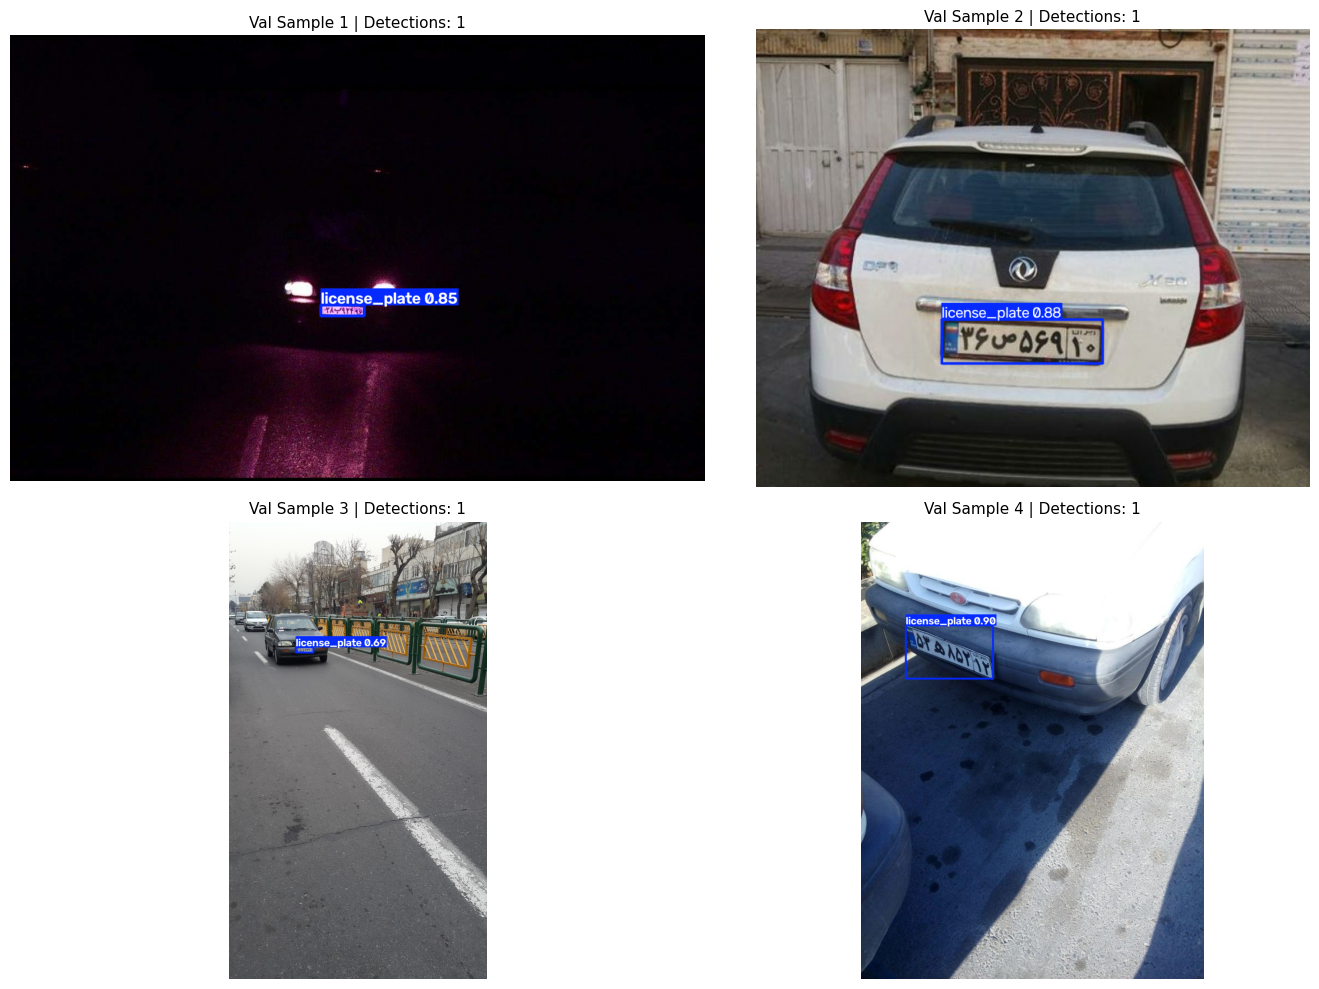

In [16]:
import glob
import random
import cv2
import matplotlib.pyplot as plt

# Pick 4 random validation images
val_images = glob.glob("/content/LPD_FILES/images/val/*.jpg")
sample_images = random.sample(val_images, 4)

# Run prediction
results = lpd_model(sample_images, conf=0.25)

# Plot side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (res, ax) in enumerate(zip(results, axes)):
    # res.plot() renders boxes, labels, and confidence on the image in BGR
    img_plotted = res.plot()
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img_plotted, cv2.COLOR_BGR2RGB)

    ax.imshow(img_rgb)
    ax.set_title(f"Val Sample {i+1} | Detections: {len(res.boxes)}", fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:


run_dir = "/content/drive/MyDrive/License_Plate_Project/yolo_runs/lpd_experiment"

# 1. List all logged files in the experiment directory
print("Logged files in experiment directory:")
for item in sorted(os.listdir(run_dir)):
    item_path = os.path.join(run_dir, item)
    size_kb = os.path.getsize(item_path) / 1024 if os.path.isfile(item_path) else 0
    print(f" - {item:<30} {f'({size_kb:.1f} KB)' if os.path.isfile(item_path) else '[DIR]'}")

# 2. Inspect key training hyperparameters from args.yaml
args_path = os.path.join(run_dir, "args.yaml")
if os.path.exists(args_path):
    with open(args_path, "r") as f:
        args_data = yaml.safe_load(f)
    print("\nKey Hyperparameters logged in args.yaml:")
    for key in ['model', 'data', 'epochs', 'batch', 'imgsz', 'optimizer', 'lr0', 'lrf']:
        print(f" - {key}: {args_data.get(key)}")

Logged files in experiment directory:
 - BoxF1_curve.png                (106.8 KB)
 - BoxPR_curve.png                (83.8 KB)
 - BoxP_curve.png                 (91.8 KB)
 - BoxR_curve.png                 (104.5 KB)
 - args.yaml                      (1.9 KB)
 - confusion_matrix.png           (104.7 KB)
 - confusion_matrix_normalized.png (104.1 KB)
 - labels.jpg                     (114.2 KB)
 - results.csv                    (2.5 KB)
 - results.png                    (309.0 KB)
 - train_batch0.jpg               (543.0 KB)
 - train_batch1.jpg               (432.7 KB)
 - train_batch2.jpg               (524.8 KB)
 - train_batch3330.jpg            (384.9 KB)
 - train_batch3331.jpg            (380.2 KB)
 - train_batch3332.jpg            (366.0 KB)
 - val_batch0_labels.jpg          (389.5 KB)
 - val_batch0_pred.jpg            (400.7 KB)
 - val_batch1_labels.jpg          (303.5 KB)
 - val_batch1_pred.jpg            (320.0 KB)
 - val_batch2_labels.jpg          (381.6 KB)
 - val_batch2_pred.jpg

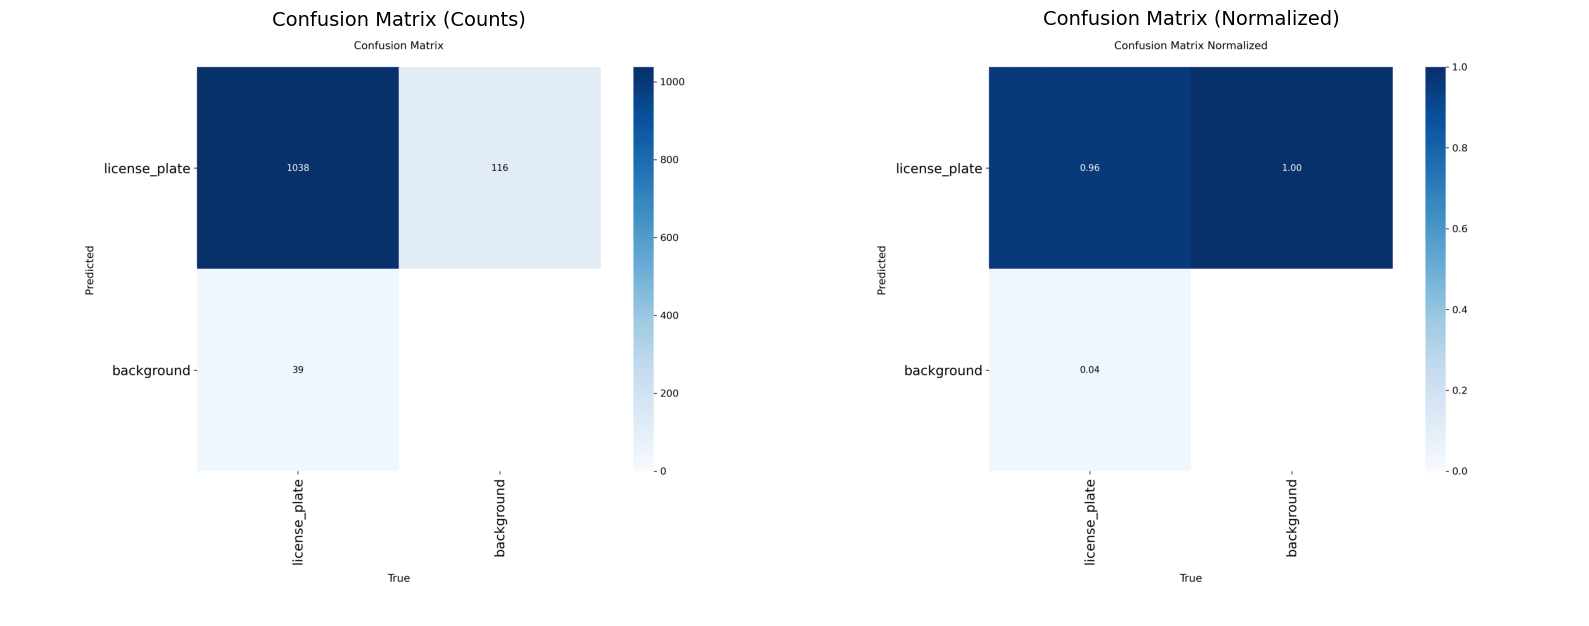

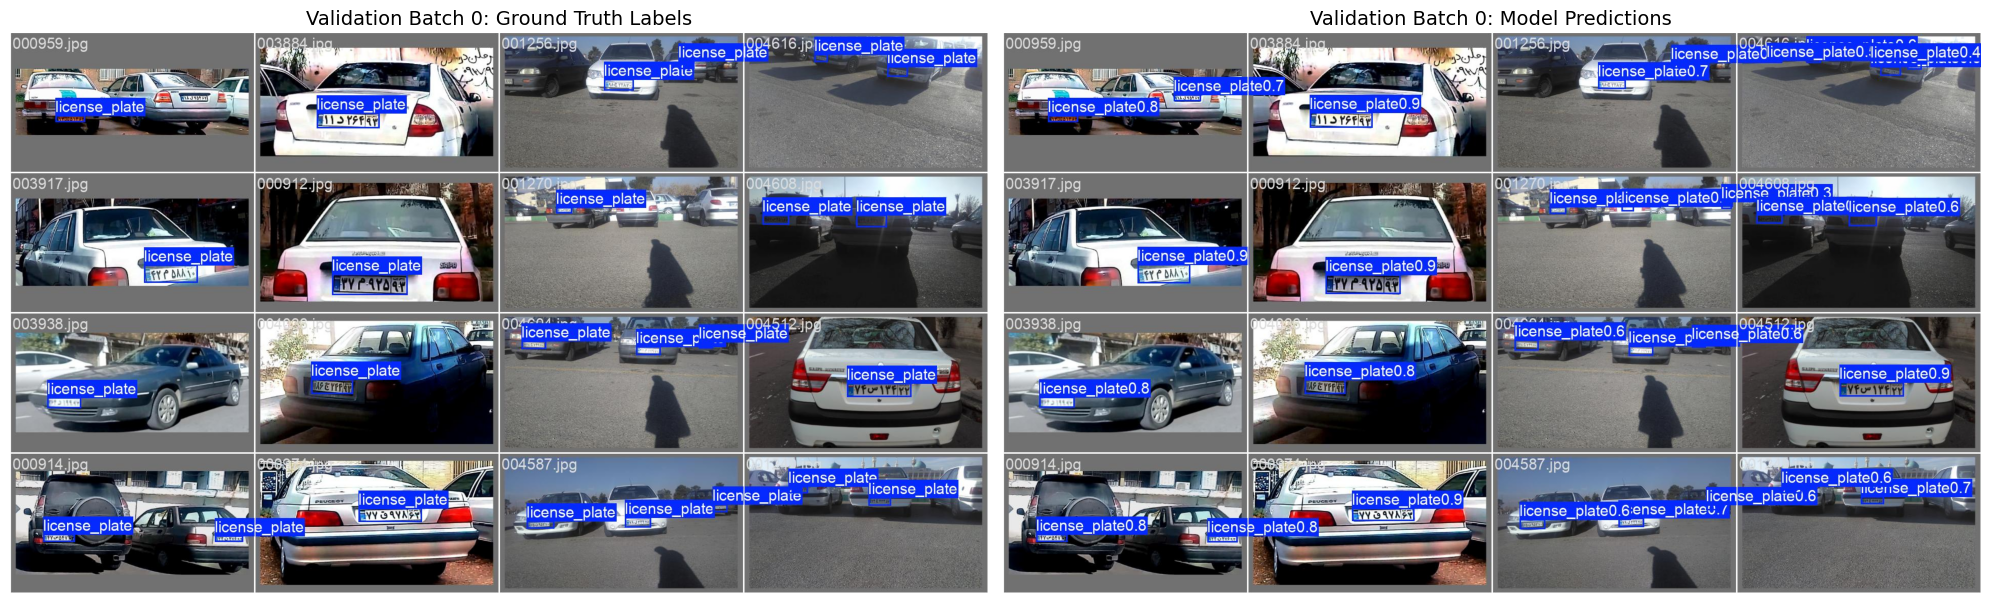

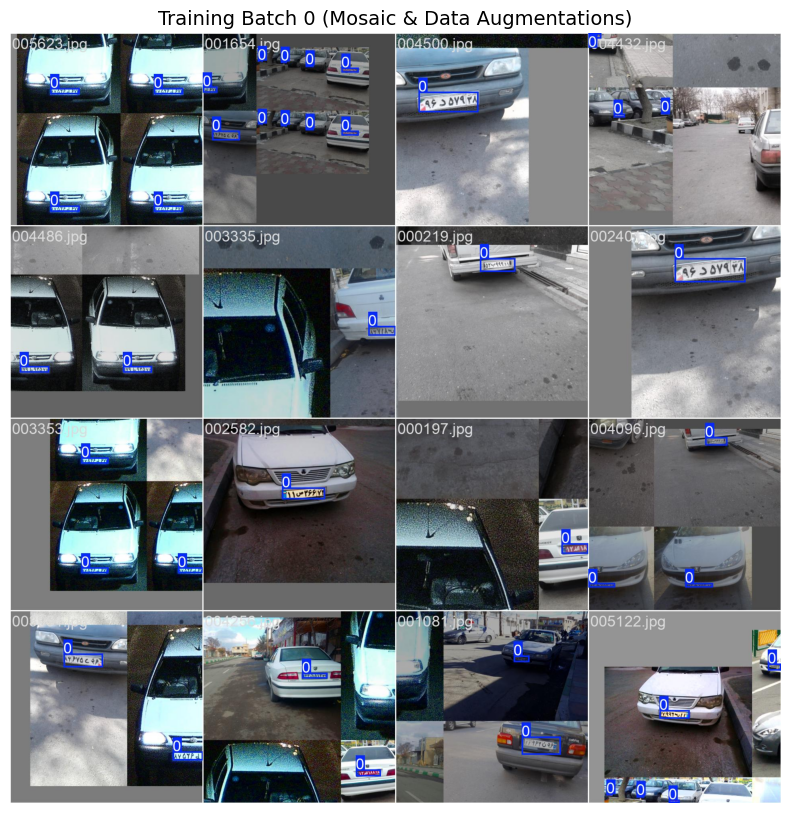

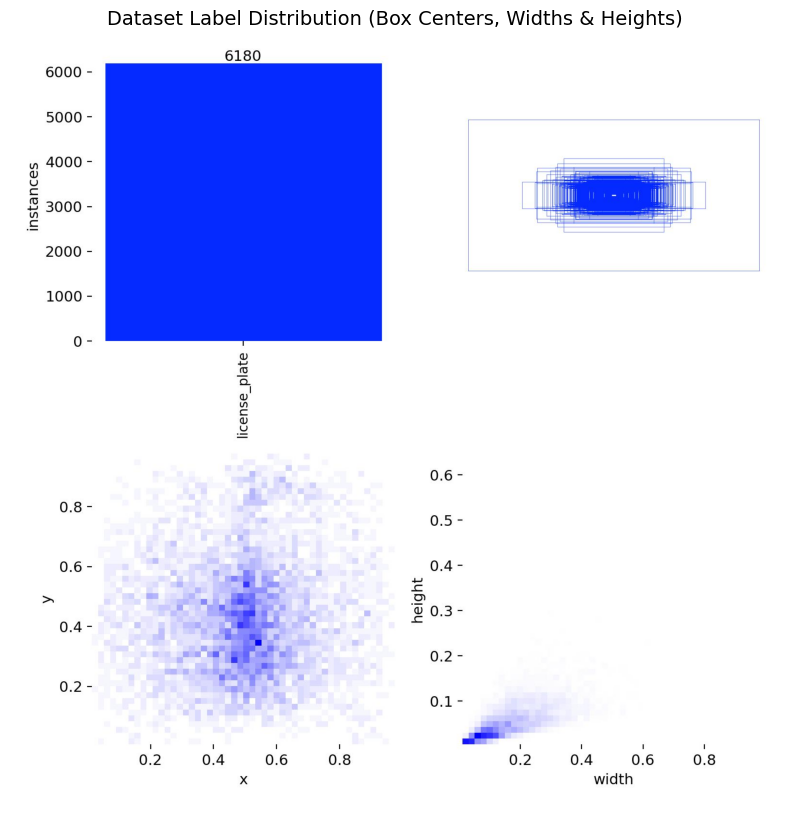

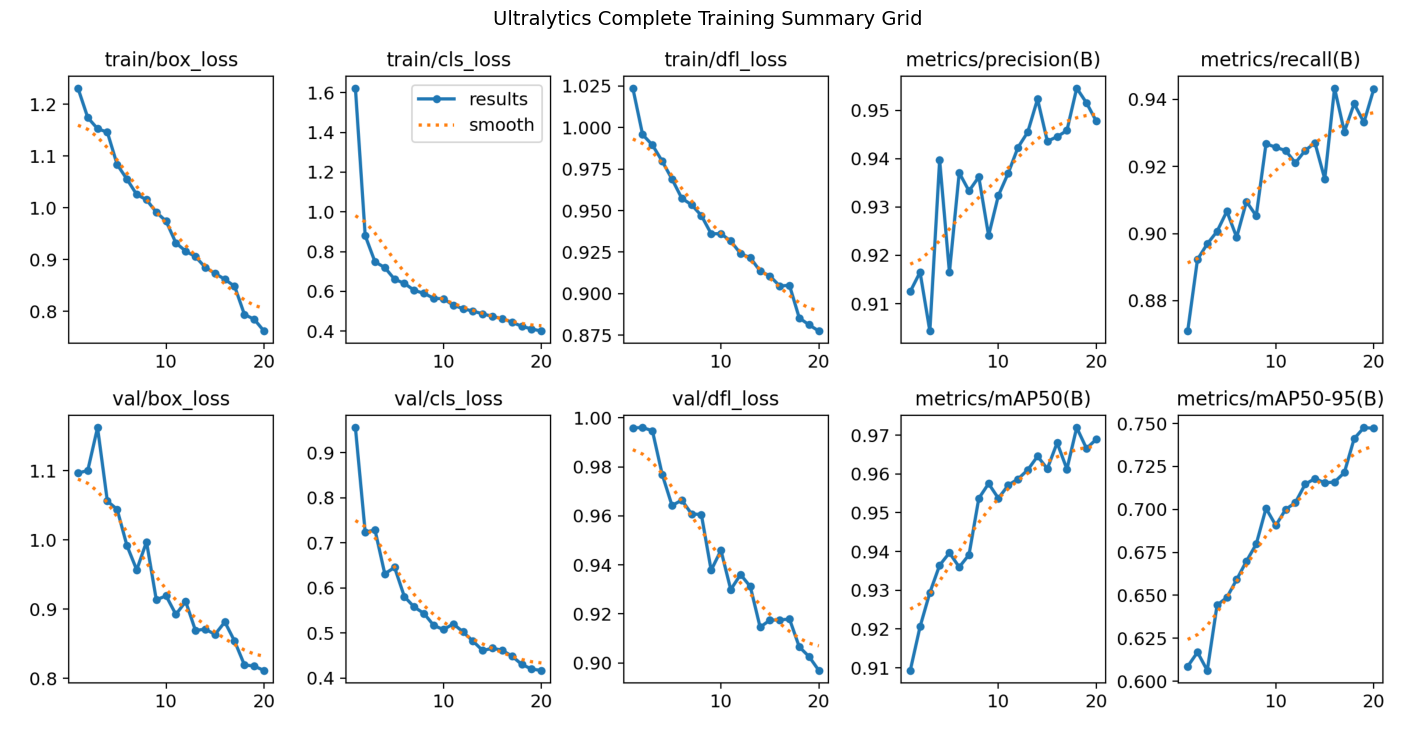

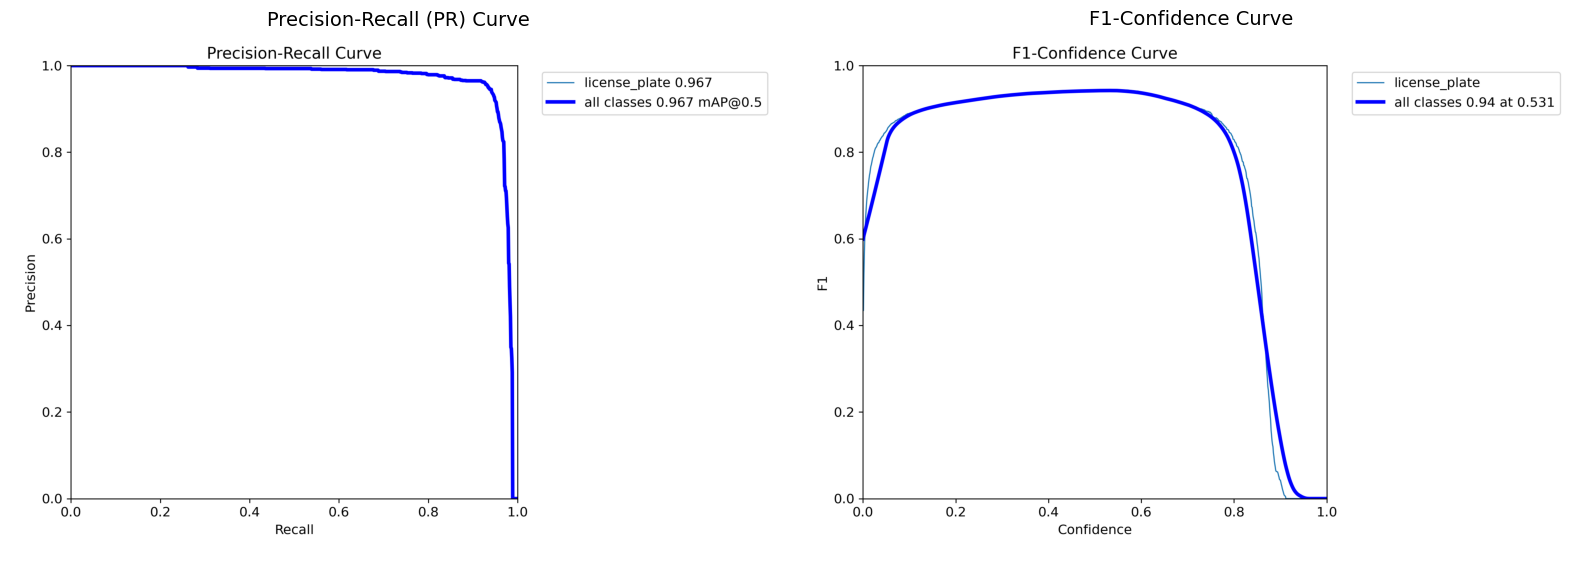

In [22]:
import os
import cv2
import matplotlib.pyplot as plt

run_dir = "/content/drive/MyDrive/License_Plate_Project/yolo_runs/lpd_experiment"

def load_img(filename):
    """Helper to safely load an image from the run directory in RGB format."""
    path = os.path.join(run_dir, filename)
    if os.path.exists(path):
        img = cv2.imread(path)
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return None

# ==========================================
# 1. Confusion Matrices (Raw vs Normalized)
# ==========================================
cm = load_img("confusion_matrix.png")
cm_norm = load_img("confusion_matrix_normalized.png")

if cm is not None or cm_norm is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    if cm is not None:
        axes[0].imshow(cm)
        axes[0].set_title("Confusion Matrix (Counts)", fontsize=14)
        axes[0].axis("off")
    if cm_norm is not None:
        axes[1].imshow(cm_norm)
        axes[1].set_title("Confusion Matrix (Normalized)", fontsize=14)
        axes[1].axis("off")
    plt.tight_layout()
    plt.show()

# ==========================================
# 2. Performance Curves: PR Curve & F1 Curve
# ==========================================
pr_curve = load_img("PR_curve.png")
f1_curve = load_img("F1_curve.png")

if pr_curve is not None or f1_curve is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    if pr_curve is not None:
        axes[0].imshow(pr_curve)
        axes[0].set_title("Precision-Recall (PR) Curve", fontsize=14)
        axes[0].axis("off")
    if f1_curve is not None:
        axes[1].imshow(f1_curve)
        axes[1].set_title("F1-Confidence Curve", fontsize=14)
        axes[1].axis("off")
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. Ground Truth vs Predictions (Validation Batch)
# ==========================================
val_labels = load_img("val_batch0_labels.jpg")
val_preds = load_img("val_batch0_pred.jpg")

if val_labels is not None or val_preds is not None:
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    if val_labels is not None:
        axes[0].imshow(val_labels)
        axes[0].set_title("Validation Batch 0: Ground Truth Labels", fontsize=14)
        axes[0].axis("off")
    if val_preds is not None:
        axes[1].imshow(val_preds)
        axes[1].set_title("Validation Batch 0: Model Predictions", fontsize=14)
        axes[1].axis("off")
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. Training Data Augmentations (Mosaic Batch 0)
# ==========================================
train_batch = load_img("train_batch0.jpg")
if train_batch is not None:
    plt.figure(figsize=(14, 10))
    plt.imshow(train_batch)
    plt.title("Training Batch 0 (Mosaic & Data Augmentations)", fontsize=14)
    plt.axis("off")
    plt.show()

# ==========================================
# 5. Label Distribution & Geometry Analysis
# ==========================================
labels_stat = load_img("labels.jpg")
if labels_stat is not None:
    plt.figure(figsize=(14, 10))
    plt.imshow(labels_stat)
    plt.title("Dataset Label Distribution (Box Centers, Widths & Heights)", fontsize=14)
    plt.axis("off")
    plt.show()

# ==========================================
# 6. Full Training Overview Summary Grid
# ==========================================
results_summary = load_img("results.png")
if results_summary is not None:
    plt.figure(figsize=(18, 10))
    plt.imshow(results_summary)
    plt.title("Ultralytics Complete Training Summary Grid", fontsize=14)
    plt.axis("off")
    plt.show()


# Check for both naming conventions
f1_name = "BoxF1_curve.png" if os.path.exists(os.path.join(run_dir, "BoxF1_curve.png")) else "F1_curve.png"
pr_name = "BoxPR_curve.png" if os.path.exists(os.path.join(run_dir, "BoxPR_curve.png")) else "PR_curve.png"

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, fname, title in zip(axes, [pr_name, f1_name], ["Precision-Recall (PR) Curve", "F1-Confidence Curve"]):
    path = os.path.join(run_dir, fname)
    if os.path.exists(path):
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(title, fontsize=14)
        ax.axis("off")

plt.tight_layout()
plt.show()

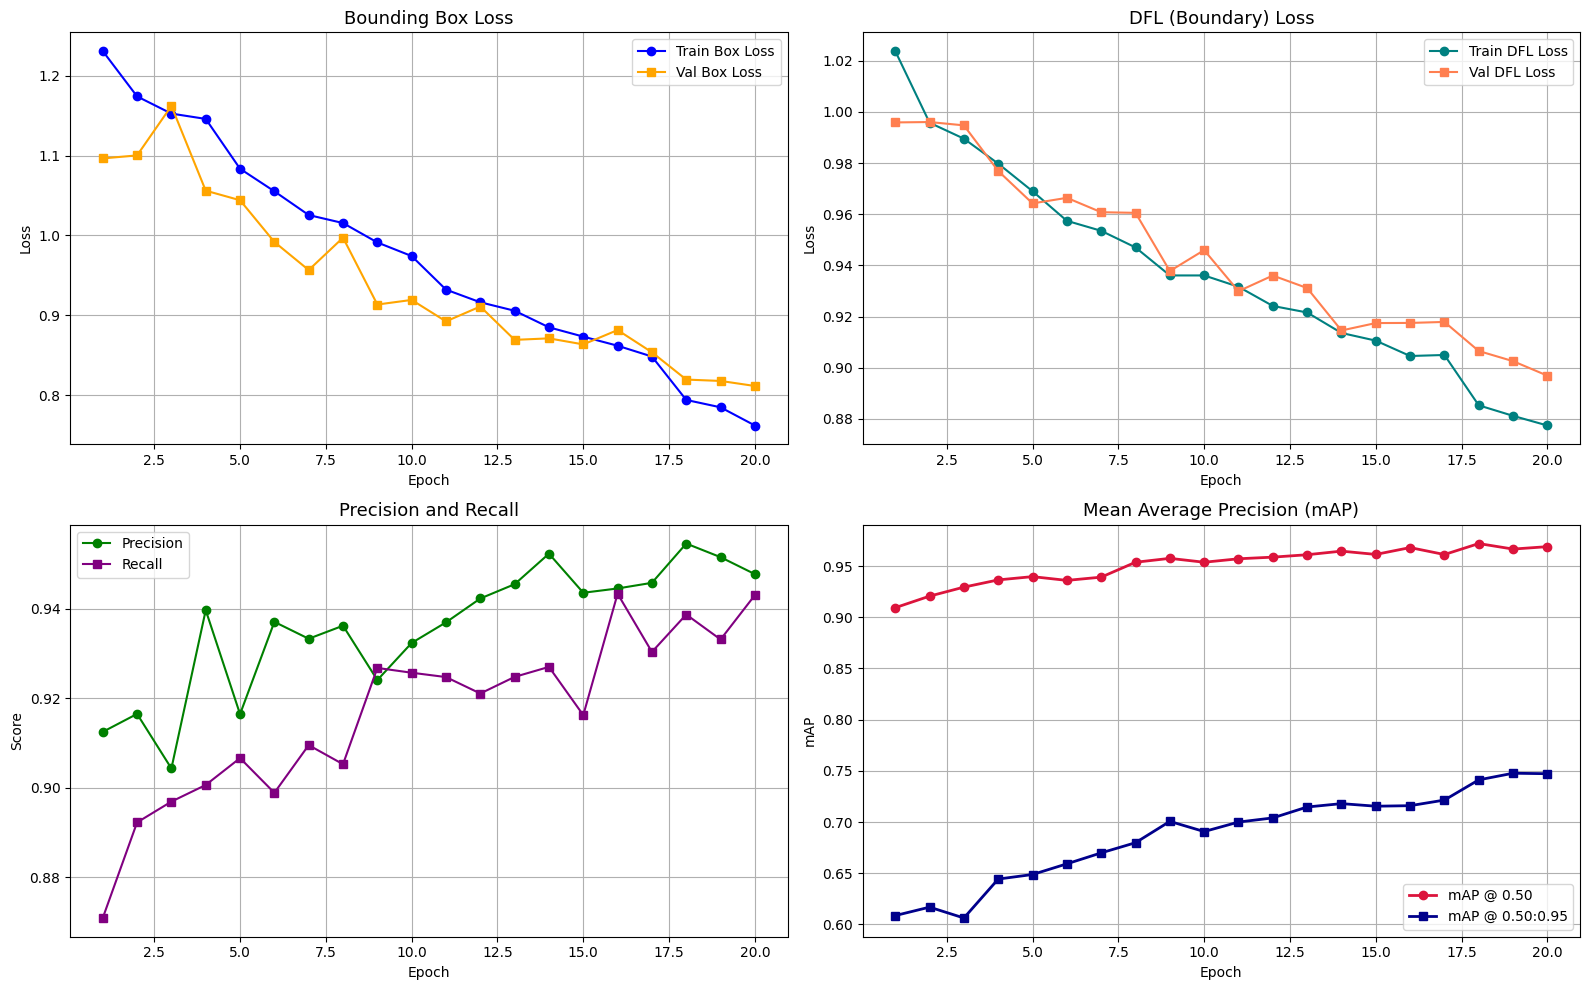

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import os

results_csv = "/content/drive/MyDrive/License_Plate_Project/yolo_runs/lpd_experiment/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()  # Strip spaces from column names

epochs = df['epoch']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Box Loss (Train vs Val)
axes[0, 0].plot(epochs, df['train/box_loss'], label='Train Box Loss', color='blue', marker='o')
axes[0, 0].plot(epochs, df['val/box_loss'], label='Val Box Loss', color='orange', marker='s')
axes[0, 0].set_title('Bounding Box Loss', fontsize=13)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. DFL Loss (Distribution Focal Loss - box boundary refinement)
axes[0, 1].plot(epochs, df['train/dfl_loss'], label='Train DFL Loss', color='teal', marker='o')
axes[0, 1].plot(epochs, df['val/dfl_loss'], label='Val DFL Loss', color='coral', marker='s')
axes[0, 1].set_title('DFL (Boundary) Loss', fontsize=13)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. Precision & Recall
axes[1, 0].plot(epochs, df['metrics/precision(B)'], label='Precision', color='green', marker='o')
axes[1, 0].plot(epochs, df['metrics/recall(B)'], label='Recall', color='purple', marker='s')
axes[1, 0].set_title('Precision and Recall', fontsize=13)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 4. mAP50 and mAP50-95
axes[1, 1].plot(epochs, df['metrics/mAP50(B)'], label='mAP @ 0.50', color='crimson', marker='o', linewidth=2)
axes[1, 1].plot(epochs, df['metrics/mAP50-95(B)'], label='mAP @ 0.50:0.95', color='darkblue', marker='s', linewidth=2)
axes[1, 1].set_title('Mean Average Precision (mAP)', fontsize=13)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('mAP')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [19]:
# Run official validation using best weights
metrics = lpd_model.val(data="/content/data.yaml", split="val")

# Display a clean report summary
print("\n" + "="*50)
print("       FINAL LPD (YOLOv8n) EVALUATION SUMMARY")
print("="*50)
print(f"Validation Images Evaluated : {metrics.box.nc} class, {len(val_images)} images")
print(f"Precision                   : {metrics.box.mp:.4f} ({metrics.box.mp*100:.2f}%)")
print(f"Recall                      : {metrics.box.mr:.4f} ({metrics.box.mr*100:.2f}%)")
print(f"mAP @ 0.50                  : {metrics.box.map50:.4f} ({metrics.box.map50*100:.2f}%)")
print(f"mAP @ 0.50:0.95             : {metrics.box.map:.4f} ({metrics.box.map*100:.2f}%)")
print(f"Inference Latency (Pre/Inf) : {metrics.speed['preprocess']:.2f}ms / {metrics.speed['inference']:.2f}ms per image")
print("="*50)

Ultralytics 8.4.159 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 809.2±1581.1 MB/s, size: 500.6 KB)
val: Scanning /content/LPD_FILES/labels/val... 938 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 938/938 517.2it/s 1.8s
val: New cache created: /content/LPD_FILES/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 3.5it/s 17.0s
                   all        938       1077      0.952      0.934      0.969      0.748
Speed: 1.4ms preprocess, 3.6ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val

       FINAL LPD (YOLOv8n) EVALUATION SUMMARY
Validation Images Evaluated : 1 class, 938 images
Precision                   : 0.9524 (95.24%)
Recall                      : 0.9341 (93.41%)
mAP @ 0.50                  : 0.969